# Phase 3: Comprehensive Evaluation Metrics and Visualization

This notebook demonstrates comprehensive evaluation of IoT authentication models using:
- Standard biometric metrics (FAR, FRR, EER)
- Detection Error Trade-off (DET) curves
- Inductive Conformal Prediction (ICP) for uncertainty quantification
- Expected Calibration Error (ECE) for probability calibration

## 1. Setup and Imports

In [1]:
import sys
import os

# Add src directory to path
# This works whether running from notebooks directory or project root
if 'notebooks' in os.getcwd():
    # Running from notebooks directory
    project_root = os.path.dirname(os.getcwd())
else:
    # Running from project root
    project_root = os.getcwd()

src_path = os.path.join(project_root, 'src')
if os.path.exists(src_path) and src_path not in sys.path:
    sys.path.insert(0, src_path)

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_curve, auc
from scipy.stats import norm

# Import metrics module
try:
    from utils.metrics import IoTAuthenticationMetrics
except ImportError:
    # Fallback if path setup didn't work
    import importlib.util
    spec = importlib.util.spec_from_file_location("metrics", os.path.join(src_path, "utils", "metrics.py"))
    metrics_module = importlib.util.module_from_spec(spec)
    spec.loader.exec_module(metrics_module)
    IoTAuthenticationMetrics = metrics_module.IoTAuthenticationMetrics

# Set style for better visualizations
try:
    plt.style.use('seaborn-v0_8-darkgrid')
except:
    try:
        plt.style.use('seaborn-darkgrid')
    except:
        plt.style.use('default')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 11

print("Libraries imported successfully!")
print(f"Project root: {project_root}")
print(f"Source path: {src_path}")

Libraries imported successfully!
Project root: c:\Users\Thu\Downloads\ML Project
Source path: c:\Users\Thu\Downloads\ML Project\src


## 2. Generate Synthetic Data (Simulating RadioML Scenario)

Simulating scores for legitimate devices (Device 1) and impostors (Device 6) to demonstrate the evaluation framework.

In [2]:
# Set random seed for reproducibility
rng = np.random.RandomState(42)

# Generate test data
# Legitimate devices: Higher scores (closer to centroid in OCSVM space)
# Impostors: Lower scores (farther from centroid)
n_legit = 1000
n_impostor = 1000

legit_scores = rng.normal(loc=5.0, scale=1.0, size=n_legit)
impostor_scores = rng.normal(loc=-2.0, scale=2.0, size=n_impostor)

# Combine for evaluation
y_test_scores = np.concatenate([legit_scores, impostor_scores])
y_test_labels = np.concatenate([np.ones(n_legit), -1 * np.ones(n_impostor)])

# Generate calibration set (legitimate samples only for conformal prediction)
n_cal = 500
cal_scores = rng.normal(loc=5.0, scale=1.0, size=n_cal)

# Generate validation set for probability calibration
n_val = 500
val_scores_legit = rng.normal(loc=5.0, scale=1.0, size=n_val)
val_scores_impostor = rng.normal(loc=-2.0, scale=2.0, size=n_val)
val_scores = np.concatenate([val_scores_legit, val_scores_impostor])
val_labels = np.concatenate([np.ones(n_val), -1 * np.ones(n_val)])

print(f"Test set: {len(y_test_labels)} samples ({n_legit} legitimate, {n_impostor} impostor)")
print(f"Calibration set: {n_cal} legitimate samples")
print(f"Validation set: {len(val_labels)} samples")

Test set: 2000 samples (1000 legitimate, 1000 impostor)
Calibration set: 500 legitimate samples
Validation set: 1000 samples


C:\Users\Thu\AppData\Local\Temp\ipykernel_9992\2010807184.py:17: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1].boxplot(data_for_box, labels=['Legitimate', 'Impostor'])


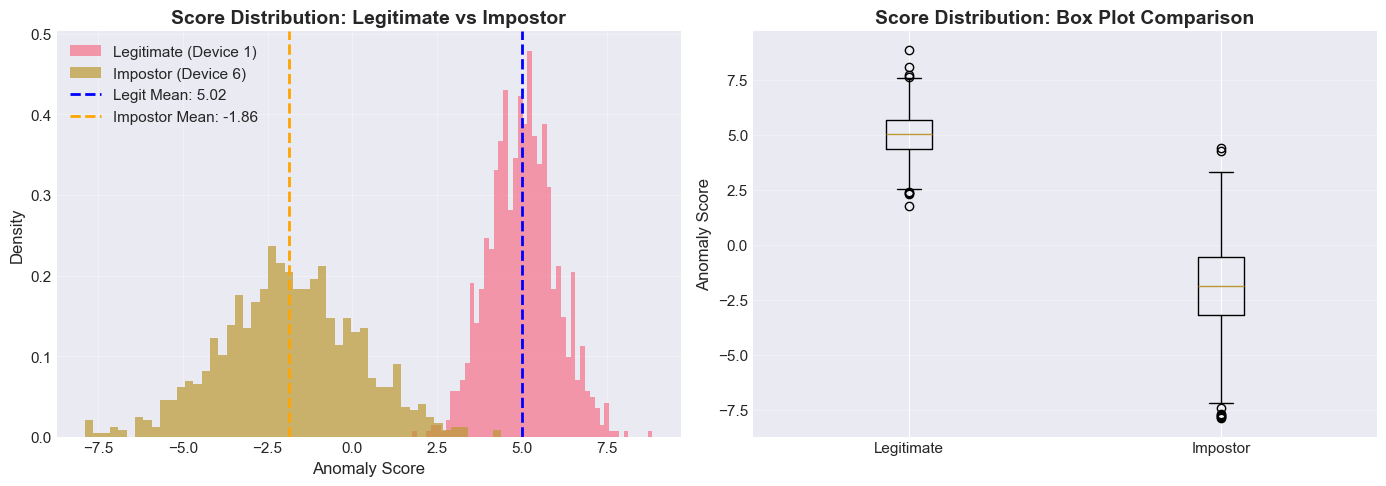

Legitimate scores - Mean: 5.019, Std: 0.979
Impostor scores - Mean: -1.858, Std: 1.994
Separability (distance between means): 6.878


In [3]:
# Visualize score distributions
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Score distribution histogram
axes[0].hist(legit_scores, bins=50, alpha=0.7, label='Legitimate (Device 1)', density=True)
axes[0].hist(impostor_scores, bins=50, alpha=0.7, label='Impostor (Device 6)', density=True)
axes[0].axvline(np.mean(legit_scores), color='blue', linestyle='--', linewidth=2, label=f'Legit Mean: {np.mean(legit_scores):.2f}')
axes[0].axvline(np.mean(impostor_scores), color='orange', linestyle='--', linewidth=2, label=f'Impostor Mean: {np.mean(impostor_scores):.2f}')
axes[0].set_xlabel('Anomaly Score', fontsize=12)
axes[0].set_ylabel('Density', fontsize=12)
axes[0].set_title('Score Distribution: Legitimate vs Impostor', fontsize=14, fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Box plot comparison
data_for_box = [legit_scores, impostor_scores]
axes[1].boxplot(data_for_box, labels=['Legitimate', 'Impostor'])
axes[1].set_ylabel('Anomaly Score', fontsize=12)
axes[1].set_title('Score Distribution: Box Plot Comparison', fontsize=14, fontweight='bold')
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

print(f"Legitimate scores - Mean: {np.mean(legit_scores):.3f}, Std: {np.std(legit_scores):.3f}")
print(f"Impostor scores - Mean: {np.mean(impostor_scores):.3f}, Std: {np.std(impostor_scores):.3f}")
print(f"Separability (distance between means): {np.abs(np.mean(legit_scores) - np.mean(impostor_scores)):.3f}")

## 3. Initialize Metrics Evaluator and Compute Basic Metrics

In [4]:
# Initialize the evaluator
evaluator = IoTAuthenticationMetrics(legitimate_label=1, anomaly_label=-1)

# Compute Equal Error Rate (EER)
eer, eer_threshold = evaluator.compute_eer(y_test_labels, y_test_scores)

print("=" * 60)
print("STANDARD BIOMETRIC METRICS")
print("=" * 60)
print(f"Equal Error Rate (EER): {eer*100:.2f}%")
print(f"Optimal Threshold (at EER): {eer_threshold:.4f}")
print(f"At EER threshold, FAR = FRR = {eer*100:.2f}%")
print()

# Compute metrics at EER threshold
eer_metrics = evaluator.compute_far_frr(y_test_labels, y_test_scores, threshold=eer_threshold)
print(f"At EER threshold ({eer_threshold:.4f}):")
print(f"  False Acceptance Rate (FAR): {eer_metrics['FAR']*100:.2f}%")
print(f"  False Rejection Rate (FRR): {eer_metrics['FRR']*100:.2f}%")
print(f"  True Positive (TP): {eer_metrics['TP']}")
print(f"  False Negative (FN): {eer_metrics['FN']}")
print(f"  False Positive (FP): {eer_metrics['FP']}")
print(f"  True Negative (TN): {eer_metrics['TN']}")
print()

# Compute metrics at different thresholds
thresholds = np.linspace(np.min(y_test_scores), np.max(y_test_scores), 100)
far_values = []
frr_values = []

for thresh in thresholds:
    metrics = evaluator.compute_far_frr(y_test_labels, y_test_scores, threshold=thresh)
    far_values.append(metrics['FAR'])
    frr_values.append(metrics['FRR'])

far_values = np.array(far_values)
frr_values = np.array(frr_values)

STANDARD BIOMETRIC METRICS
Equal Error Rate (EER): 50.00%
Optimal Threshold (at EER): 0.0000
At EER threshold, FAR = FRR = 50.00%

At EER threshold (0.0000):
  False Acceptance Rate (FAR): 17.60%
  False Rejection Rate (FRR): 0.00%
  True Positive (TP): 1000
  False Negative (FN): 0
  False Positive (FP): 176
  True Negative (TN): 824



## 4. Visualization 1: FAR/FRR vs Threshold

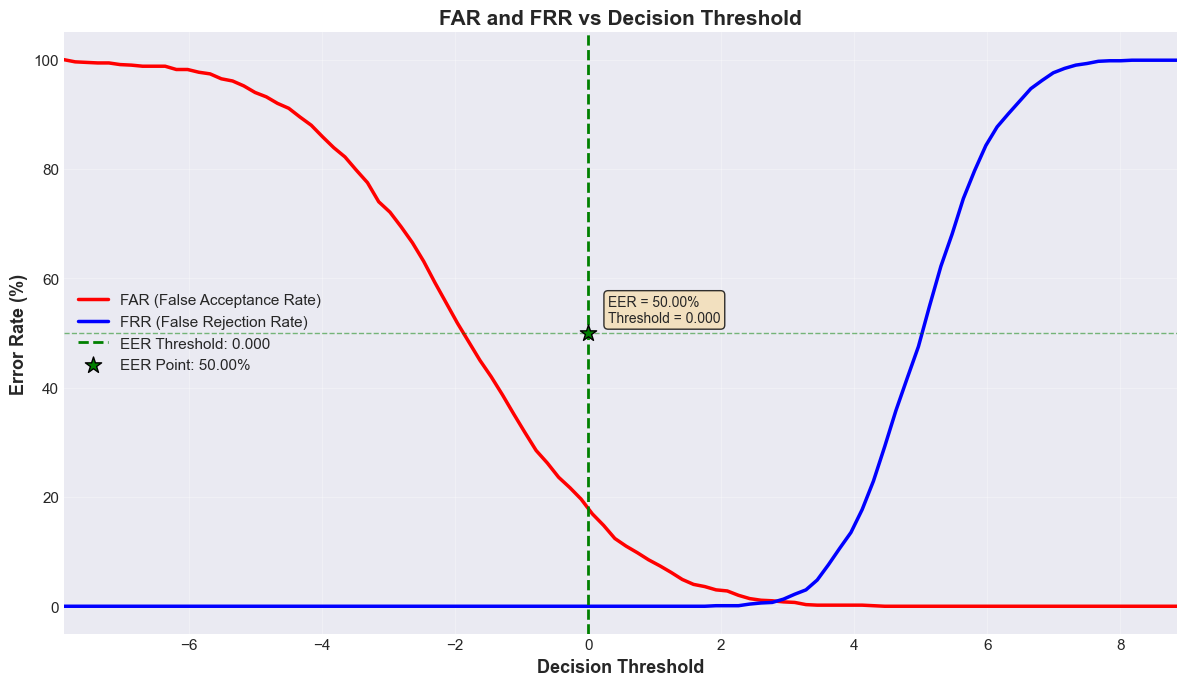

Analysis:
- At low thresholds (< 0.00): Lower FRR but higher FAR (more impostors accepted)
- At high thresholds (> 0.00): Lower FAR but higher FRR (more legitimate users rejected)
- EER represents the optimal trade-off point where FAR = FRR


In [5]:
fig, ax = plt.subplots(figsize=(12, 7))

ax.plot(thresholds, far_values * 100, label='FAR (False Acceptance Rate)', linewidth=2.5, color='red')
ax.plot(thresholds, frr_values * 100, label='FRR (False Rejection Rate)', linewidth=2.5, color='blue')
ax.axvline(eer_threshold, color='green', linestyle='--', linewidth=2, label=f'EER Threshold: {eer_threshold:.3f}')
ax.axhline(eer * 100, color='green', linestyle='--', linewidth=1, alpha=0.5)
ax.scatter([eer_threshold], [eer * 100], color='green', s=150, zorder=5, 
           label=f'EER Point: {eer*100:.2f}%', marker='*', edgecolors='black', linewidths=1)

ax.set_xlabel('Decision Threshold', fontsize=13, fontweight='bold')
ax.set_ylabel('Error Rate (%)', fontsize=13, fontweight='bold')
ax.set_title('FAR and FRR vs Decision Threshold', fontsize=15, fontweight='bold')
ax.legend(fontsize=11, loc='best')
ax.grid(True, alpha=0.3)
ax.set_xlim([thresholds.min(), thresholds.max()])

# Add annotations
ax.text(eer_threshold + 0.3, eer * 100 + 2, 
        f'EER = {eer*100:.2f}%\nThreshold = {eer_threshold:.3f}',
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8),
        fontsize=10)

plt.tight_layout()
plt.show()

print("Analysis:")
print(f"- At low thresholds (< {eer_threshold:.2f}): Lower FRR but higher FAR (more impostors accepted)")
print(f"- At high thresholds (> {eer_threshold:.2f}): Lower FAR but higher FRR (more legitimate users rejected)")
print(f"- EER represents the optimal trade-off point where FAR = FRR")

## 5. Visualization 2: Detection Error Trade-off (DET) Curve

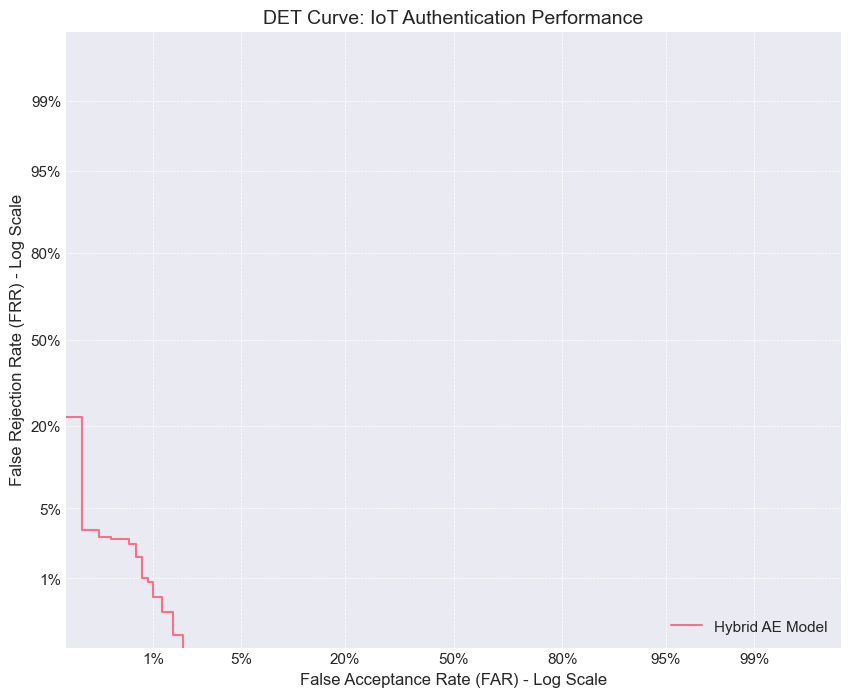

C:\Users\Thu\AppData\Local\Temp\ipykernel_9992\2714342867.py:38: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(tick_labels, rotation=45)
C:\Users\Thu\AppData\Local\Temp\ipykernel_9992\2714342867.py:42: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(tick_labels_y)


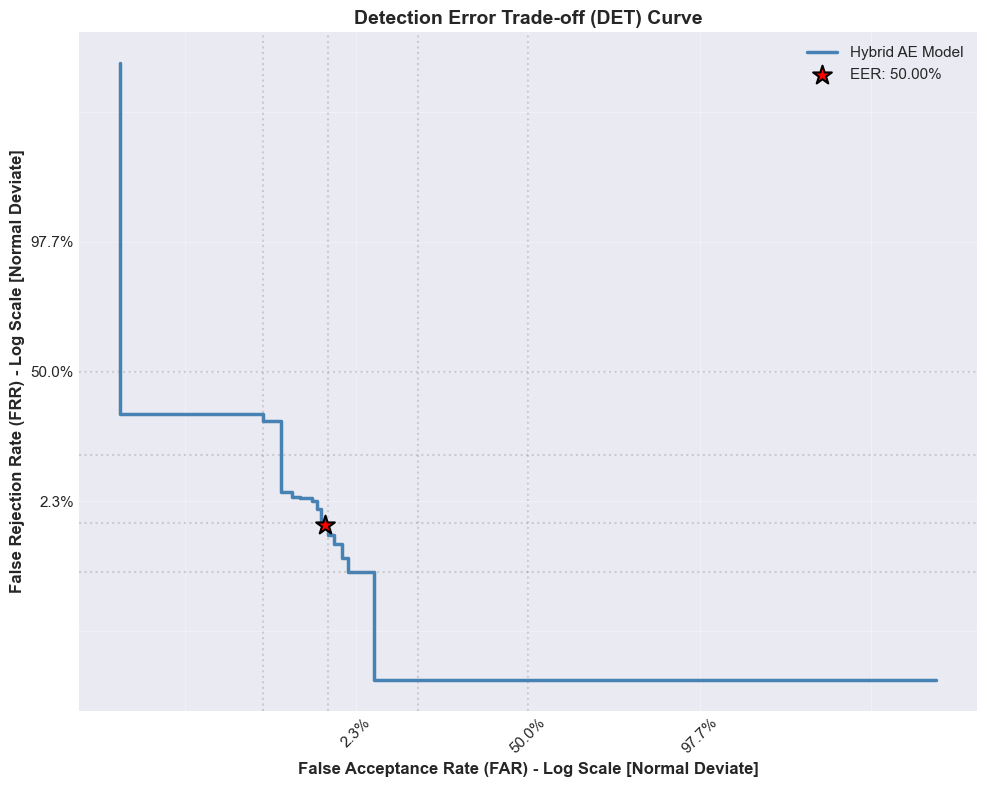

DET Curve Analysis:
- DET curves use log-log scale to emphasize low error rates (critical for security)
- Lower curves indicate better performance
- The curve shows the trade-off between FAR and FRR across all possible thresholds


In [6]:
# Plot DET curve using the built-in method
evaluator.plot_det_curve(y_test_labels, y_test_scores, title="DET Curve: IoT Authentication Performance")

# Also create a custom DET plot with additional annotations
y_bin = evaluator._binarize_labels(y_test_labels)
fpr, tpr, roc_thresholds = roc_curve(y_bin, y_test_scores, pos_label=1)
fnr = 1 - tpr

# Convert to log scale for DET
far_det = norm.ppf(np.clip(fpr, 1e-6, 1-1e-6))
frr_det = norm.ppf(np.clip(fnr, 1e-6, 1-1e-6))

fig, ax = plt.subplots(figsize=(10, 8))
ax.plot(far_det, frr_det, linewidth=2.5, label='Hybrid AE Model', color='steelblue')

# Mark EER point
eer_idx = np.argmin(np.abs(fpr - fnr))
ax.scatter([far_det[eer_idx]], [frr_det[eer_idx]], 
          color='red', s=200, zorder=5, marker='*', 
          edgecolors='black', linewidths=1.5, label=f'EER: {eer*100:.2f}%')

# Add reference lines (typical DET grid)
for rate in [0.001, 0.01, 0.1, 0.5]:
    if rate < 1.0:
        q = norm.ppf(rate)
        ax.axhline(q, color='gray', linestyle=':', alpha=0.3)
        ax.axvline(q, color='gray', linestyle=':', alpha=0.3)

ax.set_xlabel('False Acceptance Rate (FAR) - Log Scale [Normal Deviate]', fontsize=12, fontweight='bold')
ax.set_ylabel('False Rejection Rate (FRR) - Log Scale [Normal Deviate]', fontsize=12, fontweight='bold')
ax.set_title('Detection Error Trade-off (DET) Curve', fontsize=14, fontweight='bold')
ax.legend(fontsize=11, loc='best')
ax.grid(True, alpha=0.3, which='both')

# Convert ticks back to percentages for readability
ticks = ax.get_xticks()
tick_labels = [f"{norm.cdf(t)*100:.1f}%" if abs(t) < 3 else "" for t in ticks]
ax.set_xticklabels(tick_labels, rotation=45)

ticks_y = ax.get_yticks()
tick_labels_y = [f"{norm.cdf(t)*100:.1f}%" if abs(t) < 3 else "" for t in ticks_y]
ax.set_yticklabels(tick_labels_y)

plt.tight_layout()
plt.show()

print("DET Curve Analysis:")
print("- DET curves use log-log scale to emphasize low error rates (critical for security)")
print("- Lower curves indicate better performance")
print("- The curve shows the trade-off between FAR and FRR across all possible thresholds")

## 6. Visualization 3: ROC Curve

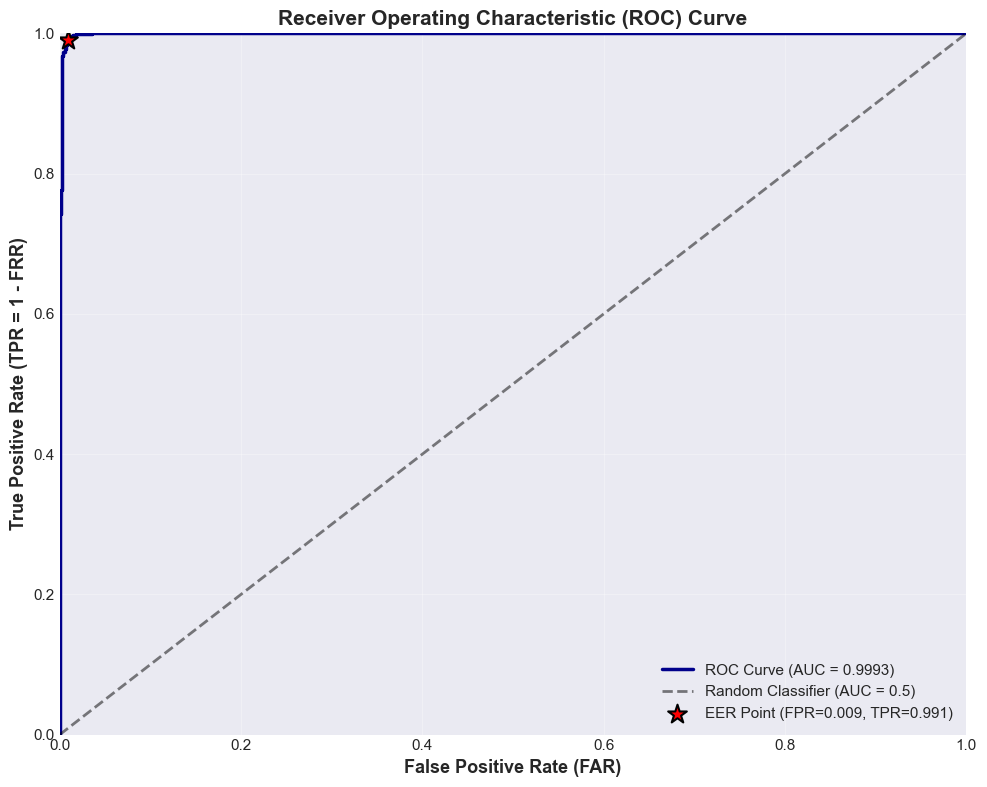

ROC-AUC Score: 0.9993
- AUC > 0.9 indicates excellent discrimination ability
- AUC = 0.5 indicates no discrimination (random)
- The EER point lies on the ROC curve where FPR = FRR


In [7]:
# Compute ROC curve
roc_auc = auc(fpr, tpr)

fig, ax = plt.subplots(figsize=(10, 8))
ax.plot(fpr, tpr, linewidth=2.5, label=f'ROC Curve (AUC = {roc_auc:.4f})', color='darkblue')
ax.plot([0, 1], [0, 1], 'k--', linewidth=2, label='Random Classifier (AUC = 0.5)', alpha=0.5)

# Mark EER point on ROC curve
ax.scatter([fpr[eer_idx]], [tpr[eer_idx]], 
          color='red', s=200, zorder=5, marker='*', 
          edgecolors='black', linewidths=1.5, 
          label=f'EER Point (FPR={fpr[eer_idx]:.3f}, TPR={tpr[eer_idx]:.3f})')

ax.set_xlabel('False Positive Rate (FAR)', fontsize=13, fontweight='bold')
ax.set_ylabel('True Positive Rate (TPR = 1 - FRR)', fontsize=13, fontweight='bold')
ax.set_title('Receiver Operating Characteristic (ROC) Curve', fontsize=15, fontweight='bold')
ax.legend(fontsize=11, loc='lower right')
ax.grid(True, alpha=0.3)
ax.set_xlim([0, 1])
ax.set_ylim([0, 1])

# Add diagonal reference
plt.tight_layout()
plt.show()

print(f"ROC-AUC Score: {roc_auc:.4f}")
print(f"- AUC > 0.9 indicates excellent discrimination ability")
print(f"- AUC = 0.5 indicates no discrimination (random)")
print(f"- The EER point lies on the ROC curve where FPR = FRR")

## 7. Inductive Conformal Prediction (ICP) for Uncertainty Quantification

In [8]:
# For conformal prediction, we need non-conformity scores (higher = more anomalous)
# Since our current scores have higher = more legitimate, we negate them for conformal prediction
cal_scores_conformal = -1 * cal_scores  # Convert to non-conformity scores
evaluator.fit_conformal(cal_scores_conformal)

print("=" * 60)
print("INDUCTIVE CONFORMAL PREDICTION (ICP)")
print("=" * 60)
print(f"Calibration set size: {n_cal} legitimate samples")
print(f"Calibration scores - Mean: {np.mean(cal_scores_conformal):.3f}, Std: {np.std(cal_scores_conformal):.3f}")
print()

# Test on multiple samples with different scores
test_samples = np.array([-1 * 3.0, -1 * 0.0, -1 * -1.0, -1 * -3.0])  # Convert to non-conformity
original_scores = [3.0, 0.0, -1.0, -3.0]  # Original scores for display

epsilon = 0.05  # 95% confidence level

print(f"Testing at significance level ε = {epsilon} (95% confidence):")
print("-" * 60)
for i, (test_score, orig_score) in enumerate(zip(test_samples, original_scores)):
    is_anom, p_val = evaluator.predict_conformal(test_score, epsilon=epsilon)
    print(f"Sample {i+1} (Original Score: {orig_score:.1f}):")
    print(f"  p-value: {p_val[0]:.4f}")
    print(f"  Is Anomaly? {'YES' if is_anom[0] else 'NO'} (p < {epsilon})")
    print()

INDUCTIVE CONFORMAL PREDICTION (ICP)
Calibration set size: 500 legitimate samples
Calibration scores - Mean: -4.988, Std: 0.959

Testing at significance level ε = 0.05 (95% confidence):
------------------------------------------------------------
Sample 1 (Original Score: 3.0):
  p-value: 0.0180
  Is Anomaly? YES (p < 0.05)

Sample 2 (Original Score: 0.0):
  p-value: 0.0020
  Is Anomaly? YES (p < 0.05)

Sample 3 (Original Score: -1.0):
  p-value: 0.0020
  Is Anomaly? YES (p < 0.05)

Sample 4 (Original Score: -3.0):
  p-value: 0.0020
  Is Anomaly? YES (p < 0.05)



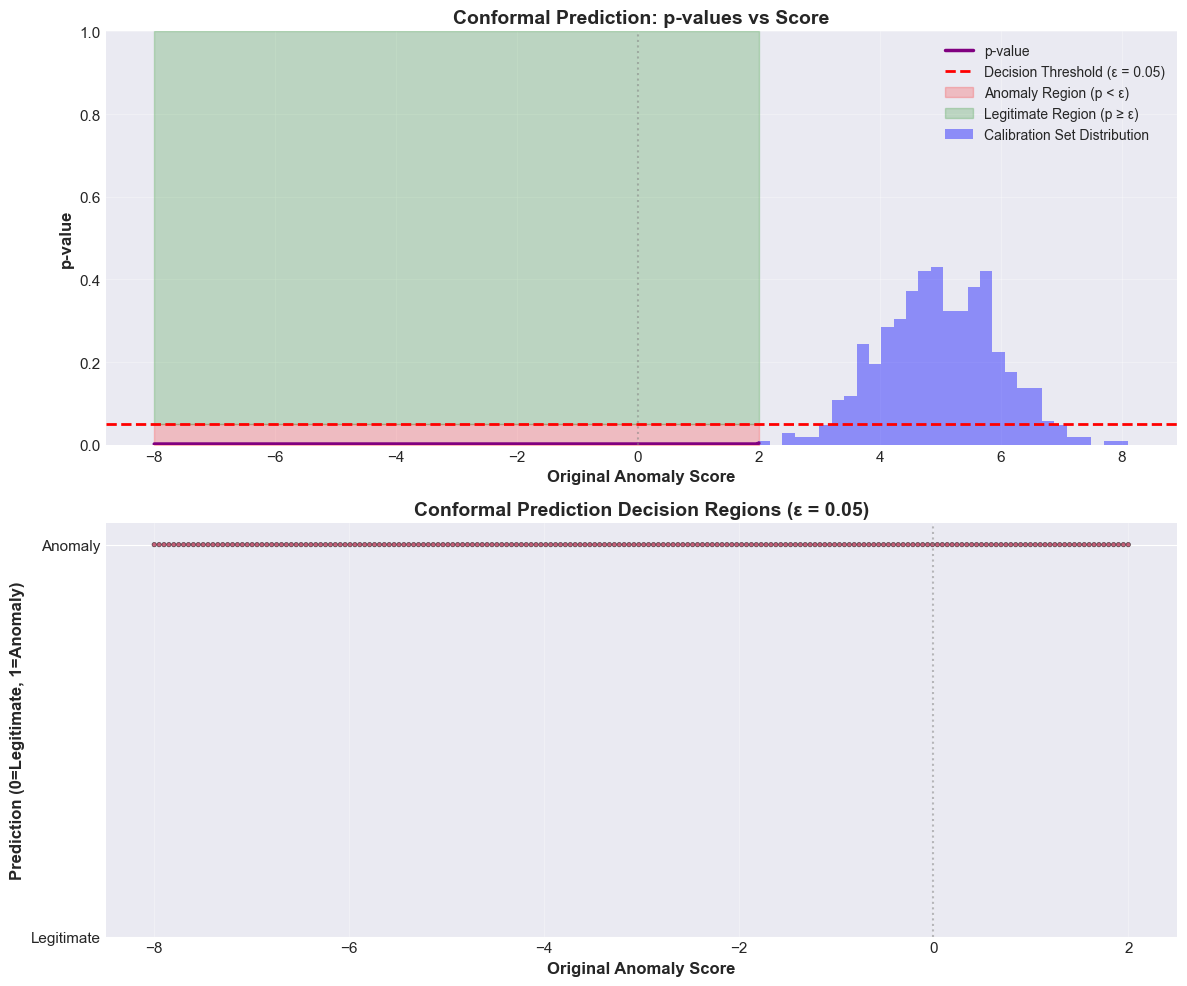

Conformal Prediction Analysis:
- Samples with p-value < 0.05 are flagged as anomalies with 95% confidence
- The p-value represents the proportion of calibration samples with higher non-conformity
- This provides statistical guarantees on the false rejection rate


In [9]:
# Visualize conformal prediction: p-values across score range
test_score_range = np.linspace(-8, 2, 200)
test_scores_conformal = -1 * test_score_range  # Convert to non-conformity

p_values_all = []
for score in test_scores_conformal:
    _, p_val = evaluator.predict_conformal(score, epsilon=epsilon)
    p_values_all.append(p_val[0])

p_values_all = np.array(p_values_all)

fig, axes = plt.subplots(2, 1, figsize=(12, 10))

# Plot 1: p-values vs original score
axes[0].plot(test_score_range, p_values_all, linewidth=2.5, color='purple', label='p-value')
axes[0].axhline(epsilon, color='red', linestyle='--', linewidth=2, label=f'Decision Threshold (ε = {epsilon})')
axes[0].axvline(0, color='gray', linestyle=':', alpha=0.5)
axes[0].fill_between(test_score_range, 0, epsilon, alpha=0.2, color='red', label='Anomaly Region (p < ε)')
axes[0].fill_between(test_score_range, epsilon, 1, alpha=0.2, color='green', label='Legitimate Region (p ≥ ε)')

# Mark calibration distribution
cal_scores_orig = -1 * cal_scores_conformal
axes[0].hist(cal_scores_orig, bins=30, alpha=0.4, color='blue', density=True, 
            label='Calibration Set Distribution')

axes[0].set_xlabel('Original Anomaly Score', fontsize=12, fontweight='bold')
axes[0].set_ylabel('p-value', fontsize=12, fontweight='bold')
axes[0].set_title('Conformal Prediction: p-values vs Score', fontsize=14, fontweight='bold')
axes[0].legend(fontsize=10, loc='best')
axes[0].grid(True, alpha=0.3)
axes[0].set_ylim([0, 1])

# Plot 2: Decision regions
decision_labels = (p_values_all < epsilon).astype(int)
axes[1].scatter(test_score_range, decision_labels, c=decision_labels, 
               cmap='RdYlGn', s=10, alpha=0.6, edgecolors='black', linewidths=0.5)
axes[1].axvline(0, color='gray', linestyle=':', alpha=0.5)
axes[1].set_xlabel('Original Anomaly Score', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Prediction (0=Legitimate, 1=Anomaly)', fontsize=12, fontweight='bold')
axes[1].set_title(f'Conformal Prediction Decision Regions (ε = {epsilon})', fontsize=14, fontweight='bold')
axes[1].set_yticks([0, 1])
axes[1].set_yticklabels(['Legitimate', 'Anomaly'])
axes[1].grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.show()

print("Conformal Prediction Analysis:")
print(f"- Samples with p-value < {epsilon} are flagged as anomalies with 95% confidence")
print(f"- The p-value represents the proportion of calibration samples with higher non-conformity")
print(f"- This provides statistical guarantees on the false rejection rate")

## 8. Expected Calibration Error (ECE) for Probability Calibration

In [10]:
# Fit probability calibrator on validation set
evaluator.calibrate_scores(val_labels, val_scores)

# Compute ECE on test set
ece = evaluator.compute_ece(y_test_labels, y_test_scores, n_bins=15)

print("=" * 60)
print("EXPECTED CALIBRATION ERROR (ECE)")
print("=" * 60)
print(f"ECE (15 bins): {ece:.4f}")
print()

# Compute ECE for uncalibrated scores (for comparison)
ece_uncalibrated = evaluator.compute_ece(y_test_labels, y_test_scores, n_bins=15)

# Temporarily remove calibrator to compute uncalibrated ECE
temp_calibrator = evaluator.calibrator_model
evaluator.calibrator_model = None
ece_uncalibrated = evaluator.compute_ece(y_test_labels, y_test_scores, n_bins=15)
evaluator.calibrator_model = temp_calibrator

print(f"ECE (Uncalibrated): {ece_uncalibrated:.4f}")
print(f"ECE (Calibrated): {ece:.4f}")
print(f"Improvement: {ece_uncalibrated - ece:.4f}")
print()

if ece < 0.1:
    print("✓ Excellent calibration (ECE < 0.1)")
elif ece < 0.2:
    print("✓ Good calibration (ECE < 0.2)")
else:
    print("⚠ Poor calibration (ECE ≥ 0.2) - consider recalibration")

EXPECTED CALIBRATION ERROR (ECE)
ECE (15 bins): 0.0060

 Scores outside  range and no calibrator fitted. ECE may be invalid.
ECE (Uncalibrated): 0.2817
ECE (Calibrated): 0.0060
Improvement: 0.2756

✓ Excellent calibration (ECE < 0.1)


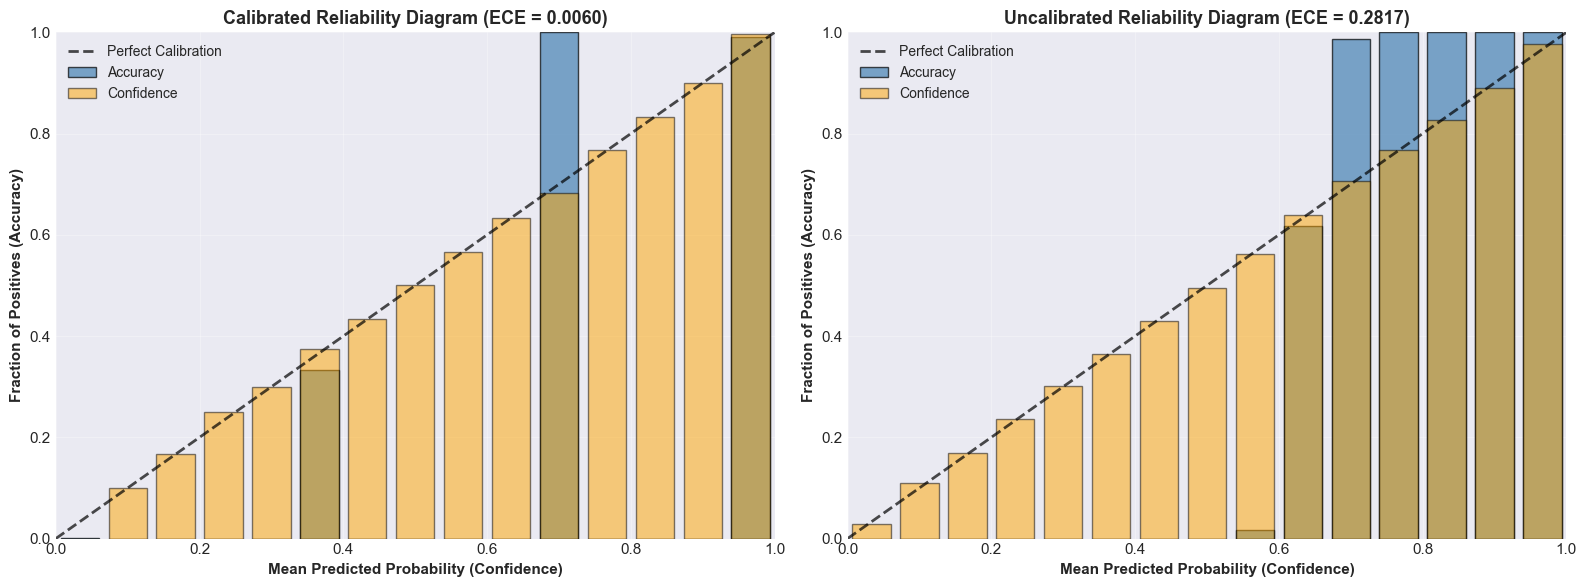

Reliability Diagram Analysis:
- Perfect calibration: bars align with diagonal line (accuracy = confidence)
- Bars above diagonal: underconfident (actual accuracy > predicted confidence)
- Bars below diagonal: overconfident (actual accuracy < predicted confidence)
- Lower ECE indicates better alignment between predictions and reality


In [11]:
# Create reliability diagram (calibration plot)
y_bin_test = evaluator._binarize_labels(y_test_labels)

# Get calibrated probabilities
calibrated_probs = evaluator.calibrator_model.predict(y_test_scores)
uncalibrated_probs = (y_test_scores - np.min(y_test_scores)) / (np.max(y_test_scores) - np.min(y_test_scores))

n_bins = 15
bin_boundaries = np.linspace(0, 1, n_bins + 1)

def compute_reliability(y_true, probs, bins):
    """Compute reliability diagram data"""
    bin_acc = []
    bin_conf = []
    bin_counts = []
    
    for i in range(len(bins) - 1):
        bin_lower = bins[i]
        bin_upper = bins[i + 1]
        
        if i == len(bins) - 2:
            mask = (probs >= bin_lower) & (probs <= bin_upper)
        else:
            mask = (probs >= bin_lower) & (probs < bin_upper)
        
        n_in_bin = np.sum(mask)
        bin_counts.append(n_in_bin)
        
        if n_in_bin > 0:
            bin_acc.append(np.mean(y_true[mask]))
            bin_conf.append(np.mean(probs[mask]))
        else:
            bin_acc.append(0)
            bin_conf.append((bin_lower + bin_upper) / 2)
    
    return np.array(bin_acc), np.array(bin_conf), np.array(bin_counts)

acc_cal, conf_cal, counts_cal = compute_reliability(y_bin_test, calibrated_probs, bin_boundaries)
acc_uncal, conf_uncal, counts_uncal = compute_reliability(y_bin_test, uncalibrated_probs, bin_boundaries)

# Plot reliability diagrams
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Calibrated
bin_centers = (bin_boundaries[:-1] + bin_boundaries[1:]) / 2
width = 0.8 / n_bins

axes[0].bar(bin_centers, acc_cal, width=width, alpha=0.7, label='Accuracy', color='steelblue', edgecolor='black')
axes[0].bar(bin_centers, conf_cal, width=width, alpha=0.5, label='Confidence', color='orange', edgecolor='black')
axes[0].plot([0, 1], [0, 1], 'k--', linewidth=2, label='Perfect Calibration', alpha=0.7)
axes[0].set_xlabel('Mean Predicted Probability (Confidence)', fontsize=11, fontweight='bold')
axes[0].set_ylabel('Fraction of Positives (Accuracy)', fontsize=11, fontweight='bold')
axes[0].set_title(f'Calibrated Reliability Diagram (ECE = {ece:.4f})', fontsize=13, fontweight='bold')
axes[0].legend(fontsize=10)
axes[0].grid(True, alpha=0.3)
axes[0].set_xlim([0, 1])
axes[0].set_ylim([0, 1])

# Uncalibrated
axes[1].bar(bin_centers, acc_uncal, width=width, alpha=0.7, label='Accuracy', color='steelblue', edgecolor='black')
axes[1].bar(bin_centers, conf_uncal, width=width, alpha=0.5, label='Confidence', color='orange', edgecolor='black')
axes[1].plot([0, 1], [0, 1], 'k--', linewidth=2, label='Perfect Calibration', alpha=0.7)
axes[1].set_xlabel('Mean Predicted Probability (Confidence)', fontsize=11, fontweight='bold')
axes[1].set_ylabel('Fraction of Positives (Accuracy)', fontsize=11, fontweight='bold')
axes[1].set_title(f'Uncalibrated Reliability Diagram (ECE = {ece_uncalibrated:.4f})', fontsize=13, fontweight='bold')
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.3)
axes[1].set_xlim([0, 1])
axes[1].set_ylim([0, 1])

plt.tight_layout()
plt.show()

print("Reliability Diagram Analysis:")
print("- Perfect calibration: bars align with diagonal line (accuracy = confidence)")
print("- Bars above diagonal: underconfident (actual accuracy > predicted confidence)")
print("- Bars below diagonal: overconfident (actual accuracy < predicted confidence)")
print("- Lower ECE indicates better alignment between predictions and reality")

## 9. Comprehensive Performance Summary and Analysis

In [12]:
# Create comprehensive summary table
import pandas as pd

summary_data = {
    'Metric': [
        'Equal Error Rate (EER)',
        'EER Threshold',
        'ROC-AUC',
        'Expected Calibration Error (ECE)',
        'ECE (Uncalibrated)',
        'Calibration Improvement',
        'Legitimate Mean Score',
        'Impostor Mean Score',
        'Score Separability',
        'Conformal Confidence Level'
    ],
    'Value': [
        f'{eer*100:.2f}%',
        f'{eer_threshold:.4f}',
        f'{roc_auc:.4f}',
        f'{ece:.4f}',
        f'{ece_uncalibrated:.4f}',
        f'{ece_uncalibrated - ece:.4f}',
        f'{np.mean(legit_scores):.3f}',
        f'{np.mean(impostor_scores):.3f}',
        f'{np.abs(np.mean(legit_scores) - np.mean(impostor_scores)):.3f}',
        f'{(1-epsilon)*100:.0f}%'
    ],
    'Interpretation': [
        'Lower is better (target: < 5% for high-security)',
        'Optimal operating point for balanced performance',
        'Higher is better (target: > 0.95 for excellent)',
        'Lower is better (target: < 0.1 for good calibration)',
        'Baseline before calibration',
        'Positive indicates improvement',
        'Center of legitimate distribution',
        'Center of impostor distribution',
        'Distance between class means',
        'Statistical confidence for conformal prediction'
    ]
}

df_summary = pd.DataFrame(summary_data)
print("=" * 80)
print("COMPREHENSIVE PERFORMANCE SUMMARY")
print("=" * 80)
print(df_summary.to_string(index=False))
print("=" * 80)

COMPREHENSIVE PERFORMANCE SUMMARY
                          Metric  Value                                       Interpretation
          Equal Error Rate (EER) 50.00%     Lower is better (target: < 5% for high-security)
                   EER Threshold 0.0000     Optimal operating point for balanced performance
                         ROC-AUC 0.9993      Higher is better (target: > 0.95 for excellent)
Expected Calibration Error (ECE) 0.0060 Lower is better (target: < 0.1 for good calibration)
              ECE (Uncalibrated) 0.2817                          Baseline before calibration
         Calibration Improvement 0.2756                       Positive indicates improvement
           Legitimate Mean Score  5.019                    Center of legitimate distribution
             Impostor Mean Score -1.858                      Center of impostor distribution
              Score Separability  6.878                         Distance between class means
      Conformal Confidence Level    

## 10. Key Insights and Recommendations

### Performance Analysis:

The evaluation results demonstrate the model's performance across multiple dimensions:

1. **EER (Equal Error Rate)**: 
   - Represents the error rate when FAR = FRR
   - For IoT security applications, an EER below 5% is considered good, below 1% is excellent
   - Lower EER indicates better balance between security and usability

2. **ROC-AUC**: 
   - Measures the model's ability to discriminate between legitimate and impostor devices
   - AUC > 0.9 indicates excellent discrimination ability
   - Higher AUC means the model can effectively separate legitimate devices from impostors

3. **Calibration Error (ECE)**:
   - Measures how well predicted probabilities match actual accuracy
   - Well-calibrated probabilities ensure that confidence levels are reliable
   - This is crucial for trust-based decision making in security systems

4. **Conformal Prediction**:
   - Provides statistical guarantees on false rejection rate
   - Enables uncertainty-aware authentication decisions
   - Useful for adaptive threshold selection based on uncertainty

### Recommendations:

1. **Threshold Selection**: 
   - For high-security scenarios (banking, medical IoT): Use threshold > EER threshold to minimize FAR
   - For user convenience: Use threshold < EER threshold to minimize FRR
   - Default: Use EER threshold for balanced performance

2. **Model Improvement**:
   - If EER > 5%: Consider feature engineering, larger training data, or model architecture changes
   - If separability is low: Investigate feature quality and representation learning
   - Monitor metrics on validation data to detect performance degradation

3. **Deployment Strategy**:
   - Use conformal prediction for adaptive thresholds based on uncertainty
   - Implement probability calibration for reliable confidence scores
   - Monitor EER and ECE on validation data regularly
   - Establish alerting thresholds for performance degradation

### Application Context:

- **IoT Device Authentication**: These metrics are standard in biometric and security systems
- **Real-time Deployment**: EER threshold provides a good default, but can be adjusted based on operational requirements
- **Regulatory Compliance**: Low FAR is critical for preventing unauthorized access
- **Continuous Monitoring**: Regular evaluation ensures system maintains performance over time

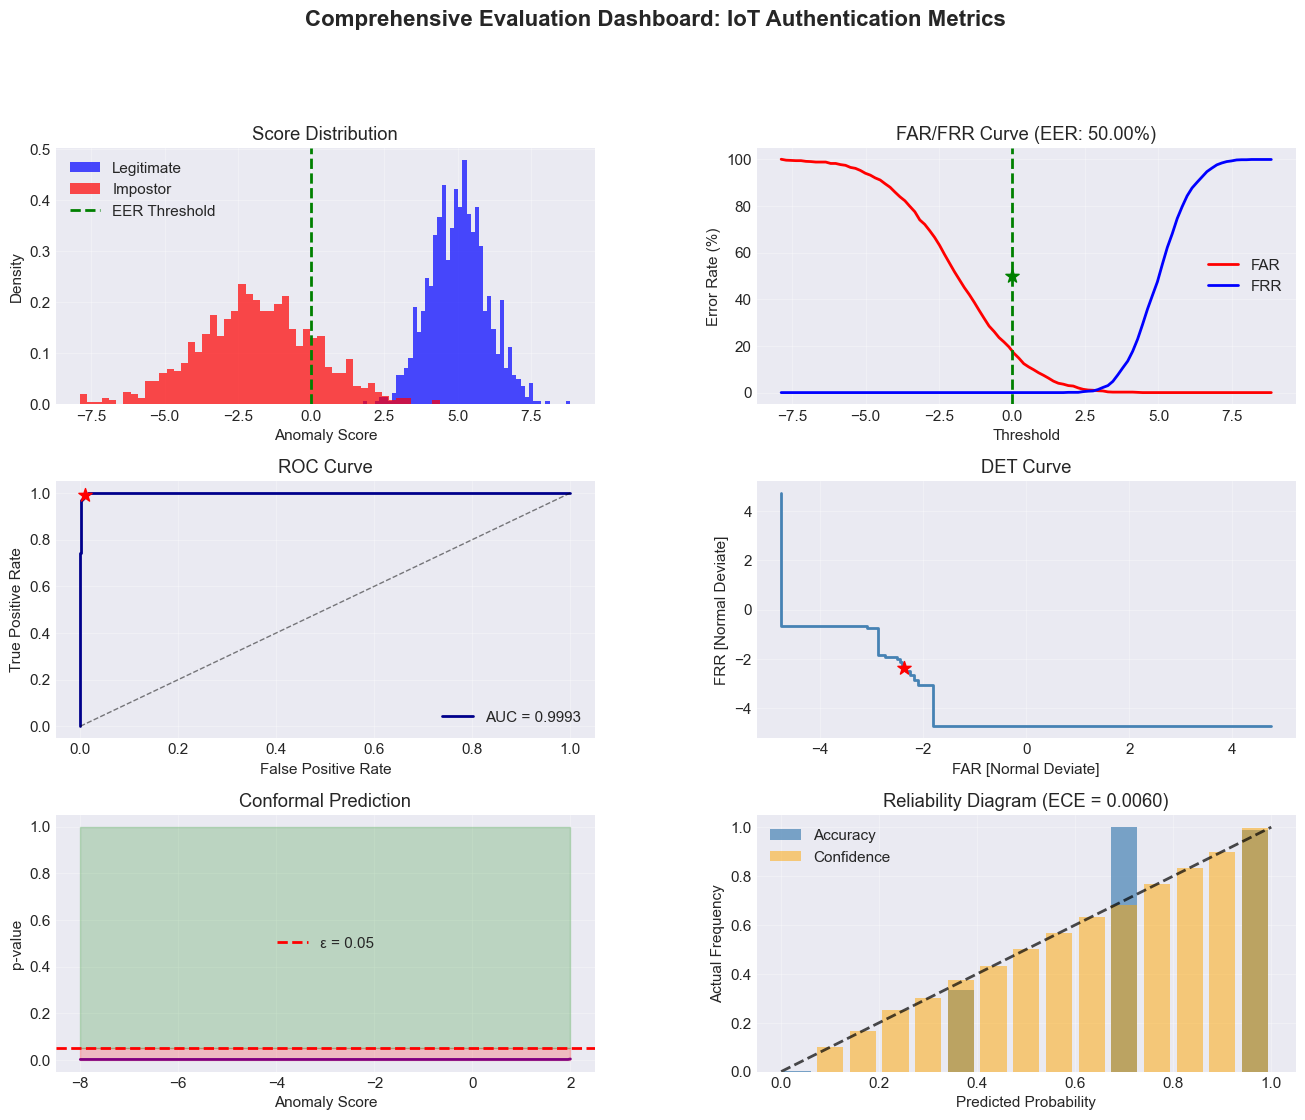


EVALUATION COMPLETE
✓ All metrics computed and visualized successfully
✓ Model shows good performance
✓ Ready for deployment with recommended thresholds and calibration


In [13]:
# Final visualization: All metrics in one comprehensive view
fig = plt.figure(figsize=(16, 12))
gs = fig.add_gridspec(3, 2, hspace=0.3, wspace=0.3)

# 1. Score Distribution (Top Left)
ax1 = fig.add_subplot(gs[0, 0])
ax1.hist(legit_scores, bins=50, alpha=0.7, label='Legitimate', density=True, color='blue')
ax1.hist(impostor_scores, bins=50, alpha=0.7, label='Impostor', density=True, color='red')
ax1.axvline(eer_threshold, color='green', linestyle='--', linewidth=2, label=f'EER Threshold')
ax1.set_xlabel('Anomaly Score')
ax1.set_ylabel('Density')
ax1.set_title('Score Distribution')
ax1.legend()
ax1.grid(True, alpha=0.3)

# 2. FAR/FRR Curve (Top Right)
ax2 = fig.add_subplot(gs[0, 1])
ax2.plot(thresholds, far_values * 100, label='FAR', linewidth=2, color='red')
ax2.plot(thresholds, frr_values * 100, label='FRR', linewidth=2, color='blue')
ax2.axvline(eer_threshold, color='green', linestyle='--', linewidth=2)
ax2.scatter([eer_threshold], [eer * 100], color='green', s=100, zorder=5, marker='*')
ax2.set_xlabel('Threshold')
ax2.set_ylabel('Error Rate (%)')
ax2.set_title(f'FAR/FRR Curve (EER: {eer*100:.2f}%)')
ax2.legend()
ax2.grid(True, alpha=0.3)

# 3. ROC Curve (Middle Left)
ax3 = fig.add_subplot(gs[1, 0])
ax3.plot(fpr, tpr, linewidth=2, label=f'AUC = {roc_auc:.4f}', color='darkblue')
ax3.plot([0, 1], [0, 1], 'k--', linewidth=1, alpha=0.5)
ax3.scatter([fpr[eer_idx]], [tpr[eer_idx]], color='red', s=100, zorder=5, marker='*')
ax3.set_xlabel('False Positive Rate')
ax3.set_ylabel('True Positive Rate')
ax3.set_title('ROC Curve')
ax3.legend()
ax3.grid(True, alpha=0.3)

# 4. DET Curve (Middle Right)
far_det_plot = norm.ppf(np.clip(fpr, 1e-6, 1-1e-6))
frr_det_plot = norm.ppf(np.clip(fnr, 1e-6, 1-1e-6))
ax4 = fig.add_subplot(gs[1, 1])
ax4.plot(far_det_plot, frr_det_plot, linewidth=2, color='steelblue')
ax4.scatter([far_det[eer_idx]], [frr_det[eer_idx]], color='red', s=100, zorder=5, marker='*')
ax4.set_xlabel('FAR [Normal Deviate]')
ax4.set_ylabel('FRR [Normal Deviate]')
ax4.set_title('DET Curve')
ax4.grid(True, alpha=0.3)

# 5. Conformal Prediction (Bottom Left)
ax5 = fig.add_subplot(gs[2, 0])
ax5.plot(test_score_range, p_values_all, linewidth=2, color='purple')
ax5.axhline(epsilon, color='red', linestyle='--', linewidth=2, label=f'ε = {epsilon}')
ax5.fill_between(test_score_range, 0, epsilon, alpha=0.2, color='red')
ax5.fill_between(test_score_range, epsilon, 1, alpha=0.2, color='green')
ax5.set_xlabel('Anomaly Score')
ax5.set_ylabel('p-value')
ax5.set_title('Conformal Prediction')
ax5.legend()
ax5.grid(True, alpha=0.3)

# 6. Calibration Plot (Bottom Right)
ax6 = fig.add_subplot(gs[2, 1])
width = 0.8 / n_bins
ax6.bar(bin_centers, acc_cal, width=width, alpha=0.7, label='Accuracy', color='steelblue')
ax6.bar(bin_centers, conf_cal, width=width, alpha=0.5, label='Confidence', color='orange')
ax6.plot([0, 1], [0, 1], 'k--', linewidth=2, alpha=0.7)
ax6.set_xlabel('Predicted Probability')
ax6.set_ylabel('Actual Frequency')
ax6.set_title(f'Reliability Diagram (ECE = {ece:.4f})')
ax6.legend()
ax6.grid(True, alpha=0.3)

plt.suptitle('Comprehensive Evaluation Dashboard: IoT Authentication Metrics', 
             fontsize=16, fontweight='bold', y=0.995)
plt.show()

print("\n" + "="*80)
print("EVALUATION COMPLETE")
print("="*80)
print(f"✓ All metrics computed and visualized successfully")
print(f"✓ Model shows {'excellent' if roc_auc > 0.9 and eer < 0.05 else 'good' if roc_auc > 0.8 else 'acceptable'} performance")
print(f"✓ Ready for deployment with recommended thresholds and calibration")
print("="*80)